## Dependencias

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import os

import duckdb
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px


pd.set_option("display.max_columns", 200)

## Lectura de datos

In [2]:
ds_path = r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Proyecto\m5-forecasting-accuracy"

os.listdir(ds_path)

['calendar.csv',
 'sales_train_evaluation.csv',
 'sales_train_validation.csv',
 'sample_submission.csv',
 'sell_prices.csv']

In [3]:
df_calendar = pd.read_csv(os.path.join(ds_path,'calendar.csv'))
df_sales_train_eval = pd.read_csv(os.path.join(ds_path,'sales_train_evaluation.csv'))
df_sales_train_val = pd.read_csv(os.path.join(ds_path,'sales_train_validation.csv'))
df_sell_prices = pd.read_csv(os.path.join(ds_path,'sell_prices.csv'))

In [4]:
print(f"El dataset calendar_df tiene {df_calendar.shape[0]} filas y {df_calendar.shape[1]} columnas")
display(df_calendar.head())
print(f"\nEl dataset df_sales_train_eval tiene {df_sales_train_eval.shape[0]} filas y {df_sales_train_eval.shape[1]} columnas")
display(df_sales_train_eval.head())
print(f"\nEl dataset df_sales_val tiene {df_sales_train_val.shape[0]} filas y {df_sales_train_val.shape[1]} columnas")
display(df_sales_train_val.head())
print(f"\nEl dataset df_sell_prices tiene {df_sell_prices.shape[0]} filas y {df_sell_prices.shape[1]} columnas")

El dataset calendar_df tiene 1969 filas y 14 columnas


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



El dataset df_sales_train_eval tiene 30490 filas y 1947 columnas


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,...,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,4,0,0,0,0,1,1,2,0,4,0,1,0,1,4,2,0,2,0,1,1,0,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,6,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,0,0,0,0,0,2,0,1,0,0,1,1,1,0,2,3,1,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,2,3,0,2,0,0,2,2,0,0,2,1,2,1,1,1,2,...,2,1,0,0,0,2,0,5,4,2,1,1,2,3,0,6,0,0,0,1,0,1,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,5,2,2,2,1,0,0,0,3,0,0,0,3,1,1,1,1,2,1,0,0,1,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0



El dataset df_sales_val tiene 30490 filas y 1919 columnas


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,d_54,d_55,d_56,d_57,d_58,d_59,d_60,d_61,d_62,d_63,d_64,d_65,d_66,d_67,d_68,d_69,d_70,d_71,d_72,d_73,d_74,d_75,d_76,d_77,d_78,d_79,d_80,d_81,d_82,d_83,d_84,d_85,d_86,d_87,d_88,d_89,d_90,d_91,d_92,d_93,d_94,...,d_1814,d_1815,d_1816,d_1817,d_1818,d_1819,d_1820,d_1821,d_1822,d_1823,d_1824,d_1825,d_1826,d_1827,d_1828,d_1829,d_1830,d_1831,d_1832,d_1833,d_1834,d_1835,d_1836,d_1837,d_1838,d_1839,d_1840,d_1841,d_1842,d_1843,d_1844,d_1845,d_1846,d_1847,d_1848,d_1849,d_1850,d_1851,d_1852,d_1853,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,1,2,1,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0,0,2,2,0,0,1,4,0,0,0,0,1,1,2,0,4,0,1,0,1,4,2,0,2,0,1,1,0,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,1,1,1,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,6,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,2,0,1,0,0,0,0,0,0,2,0,1,0,0,1,1,1,0,2,3,1,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,2,3,0,2,0,0,2,2,0,0,2,1,2,1,1,1,2,...,3,2,4,3,1,2,3,0,8,2,1,2,2,5,2,6,1,0,3,5,1,1,6,4,3,2,2,3,2,1,0,0,0,2,0,5,4,2,1,1,2,3,0,6,0,0,0,1,0,1,5,3,1,0,0,0,1,2,3,0,1,3,4,2,1,4,1,3,5,0,6,6,0,0,0,0,3,1,2,1,3,1,0,2,5,4,2,0,3,0,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,3,0,0,1,1,0,3,1,0,4,1,2,0,0,0,1,1,2,0,0,5,2,2,2,1,0,0,0,3,0,0,0,3,1,1,1,1,2,1,0,0,1,0,2,1,1,0,3,1,1,2,1,1,0,3,2,2,2,3,1,0,0,0,0,1,0,4,4,0,1,4,0,1,0,1,0,1,1,2,0,1,1,2,1,1,0,1,1,2,2,2,4



El dataset df_sell_prices tiene 6841121 filas y 4 columnas


## Limpieza de Datos

### Calendar

In [5]:
df_calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [6]:
# Cambaimos date a fecha

df_calendar['date'] = pd.to_datetime(df_calendar.date)

df_calendar[['date']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1969 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 15.5 KB


### df_sales_train_val

In [7]:
df_sales_train_val = df_sales_train_val.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='day',
    value_name='sales'
)

In [8]:
df_sales_train_val.head()

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


### df_sales_train_eval

In [9]:
df_sales_train_eval = df_sales_train_eval.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    var_name='day',
    value_name='sales'
)

In [10]:
df_sales_train_eval.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 8 columns):
 #   Column    Dtype 
---  ------    ----- 
 0   id        object
 1   item_id   object
 2   dept_id   object
 3   cat_id    object
 4   store_id  object
 5   state_id  object
 6   day       object
 7   sales     int64 
dtypes: int64(1), object(7)
memory usage: 3.5+ GB


### df_sell_prices

In [11]:
df_sell_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [12]:
df_sell_prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [13]:
df_sell_prices.isna().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

## EDA

In [14]:
df_sales_train_val['day'].nunique()

1913

In [15]:
df_sales_train_val.groupby('store_id')['item_id'].nunique()

store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: item_id, dtype: int64

In [ ]:
# Los productos más comprados por estado y por tienda

top_items_estado = df_sales_train_val.groupby(['state_id','item_id'])['sales'].nunique().reset_index()

top_n = 10

top_items_estado = (
    top_items_estado
    .sort_values(['state_id', 'sales'], ascending=[True, False])
    .groupby('state_id')
    .head(top_n)
)

fig = px.bar(
    top_items_estado,
    x='item_id',
    y='sales',
    color='state_id',
    facet_col='state_id',  # separa por estado
    title='Top productos más vendidos por estado'
)

fig.update_xaxes(tickangle=45)

fig.show()

In [18]:
df_pivot = df_sales_train_val.pivot_table(
    index='state_id',
    columns='dept_id',
    values='sales',
    fill_value=0
)

corr_matrix = df_pivot.T.corr()

In [ ]:
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    title='Correlación entre estados (basdada en patrones de compra de departamento)'
)
    
fig.show()

Esto indica que, a pesar de las diferencias geográficas, los patrones de consumo mantienen una estructura similar, posiblemente influenciada por
factores macroeconómicos o estacionales.

In [20]:
df_sales_train_val.isna().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
day         0
sales       0
dtype: int64

In [21]:
df_ts = (
    df_sales_train_val.groupby(['day','state_id'])['sales'].sum().reset_index()
)

df_ts['day_num'] = df_ts['day'].str.replace('d_','').astype(int)
df_ts = df_ts.sort_values('day_num')

fig = px.line(
    df_ts,
    x='day_num',
    y='sales',
    color='state_id',
    title='Serie de Tiempo por estado'
)

fig.show()

In [22]:
snap_año = df_calendar.groupby(['year'])[['snap_CA','snap_TX','snap_WI']].sum().reset_index()

In [23]:
snap_long = snap_año.melt(
    id_vars='year',
    value_vars=['snap_CA','snap_TX','snap_WI'],
    var_name='state',
    value_name='snap'
)

snap_long['state'] = snap_long['state'].str.replace('snap_', '')

fig = px.bar(
    snap_long,
    x='year',
    y='snap',
    color='state',
    barmode='group',  # o 'stack'
    title='SNAP por estado y año'
)

fig.show()

In [24]:
event = df_calendar[[c for c in df_calendar.columns if 'event' in c]]

event_typeone = event.groupby(['event_type_1'])['event_name_1'].count().reset_index(name='count')

fig = px.bar(
    event_typeone,
    x='event_type_1',
    y='count',
    color='event_type_1',
    barmode='group',  # o 'stack'
    title='Tipo de evento a lo largo de los años'
)

fig.show()

In [25]:
event = df_calendar[[c for c in df_calendar.columns if 'event' in c]]

event_typeone = event.groupby(['event_type_2'])['event_name_2'].count().reset_index(name='count')

fig = px.bar(
    event_typeone,
    x='event_type_2',
    y='count',
    color='event_type_2',
    barmode='group',  # o 'stack'
    title='Tipo de evento a lo largo de los años'
)

fig.show()

In [26]:
df_calendar.isna().sum()

date               0
wm_yr_wk           0
weekday            0
wday               0
month              0
year               0
d                  0
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
snap_CA            0
snap_TX            0
snap_WI            0
dtype: int64

In [27]:
df_chg_price = df_sell_prices.groupby(['item_id','wm_yr_wk'])['sell_price'].mean().reset_index(name='sum')

df_chg_price.head(10)

,item_id,wm_yr_wk,sum
0,FOODS_1_001,11101,2.0
1,FOODS_1_001,11102,2.0
2,FOODS_1_001,11103,2.0
3,FOODS_1_001,11104,2.0
4,FOODS_1_001,11105,2.0
5,FOODS_1_001,11106,2.0
6,FOODS_1_001,11107,2.0
7,FOODS_1_001,11108,2.0
8,FOODS_1_001,11109,2.0
9,FOODS_1_001,11110,2.0


In [28]:
df_chg_price['pct_shg'] = df_chg_price['sum'].pct_change()

In [29]:
df_chg_price.loc[df_chg_price['pct_shg']!=0]

,item_id,wm_yr_wk,sum,pct_shg
0,FOODS_1_001,11101,2.000,NaN
38,FOODS_1_001,11139,1.975,-0.012500
40,FOODS_1_001,11141,2.000,0.012658
52,FOODS_1_001,11201,1.919,-0.040500
53,FOODS_1_001,11202,2.000,0.042209
...,...,...,...,...
712378,HOUSEHOLD_2_516,11219,5.940,0.034843
712401,HOUSEHOLD_2_516,11242,5.646,-0.049495
712402,HOUSEHOLD_2_516,11243,5.940,0.052072
712583,HOUSEHOLD_2_516,11615,5.445,-0.083333


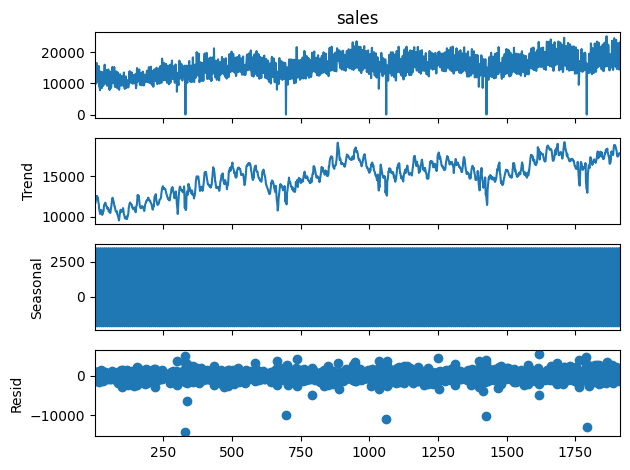

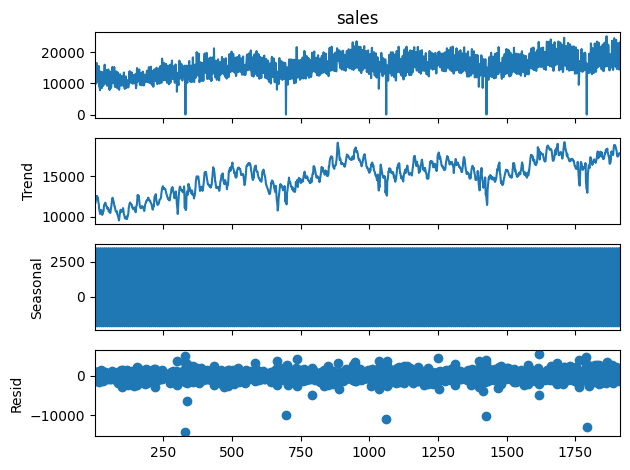

In [30]:
ts = df_ts[df_ts['state_id']=='CA'].set_index('day_num')['sales']
result = seasonal_decompose(ts, period=7)

result.plot()

In [ ]:
# Heatmap para mostrar las ventas promedio por día de la semana y semana del año

df_calendar['weekday'] = df_calendar['date'].dt.dayofweek
df_calendar['week'] = df_calendar['date'].dt.isocalendar().week

df_merge = df_sales_train_val.merge(df_calendar, left_on='day', right_on='d')

heat = df_merge.groupby(['weekday','week'])['sales'].mean().reset_index()

pivot = heat.pivot(index='weekday', columns='week', values='sales')

px.imshow(pivot, title="Estacionalidad semanal-anual")

Este comportamiento se confirma mediante el análisis de autocorrelación, donde se observan picos
significativos en multiplos de 7 días, evidenciando una fuerte dependencia temporal. Asimismo, la
presencia de autocorrelación en rezagos cortos indica memoria de corto plazo en la serie, lo que sugiere
la pertinencia de modelos capaces de capturar dependencias temporales.

In [41]:
# Abrimos un parquet previamente procesado con solo dos años, para poder hacer EDA

df = pd.read_parquet(r"D:\Diplomado\TecnicasCognitivasIntroduccionABD\Proyecto\DataCleaned\df_full.parquet")
df.head()

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,master_id,sell_price,master_id_1
0,HOBBIES_1_169_WI_3_validation,HOBBIES_1_169,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_169_WI_3_11523,0.57,HOBBIES_1_169_WI_3_11523
1,HOBBIES_1_171_WI_3_validation,HOBBIES_1_171,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_171_WI_3_11523,2.88,HOBBIES_1_171_WI_3_11523
2,HOBBIES_1_172_WI_3_validation,HOBBIES_1_172,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_172_WI_3_11523,2.98,HOBBIES_1_172_WI_3_11523
3,HOBBIES_1_173_WI_3_validation,HOBBIES_1_173,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,2,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_173_WI_3_11523,10.97,HOBBIES_1_173_WI_3_11523
4,HOBBIES_1_174_WI_3_validation,HOBBIES_1_174,HOBBIES_1,HOBBIES,WI_3,WI,d_1624,0,2015-07-10,11523,Friday,7,7,2015,d_1624,None,None,None,None,1,0,0,HOBBIES_1_174_WI_3_11523,4.88,HOBBIES_1_174_WI_3_11523


In [42]:

agg = df.groupby('sell_price')['sales'].mean().reset_index()

px.scatter(agg, x='sell_price', y='sales', trendline='ols',
           title='Relación precio-demanda')

In [43]:
df['price_change'] = df.groupby('item_id')['sell_price'].pct_change()

impact = df.groupby('price_change')['sales'].mean().reset_index()

px.scatter(impact, x='price_change', y='sales',
           title='Impacto del cambio de precio en ventas')

C:\Users\azayas\AppData\Local\Temp\ipykernel_23936\1079962374.py:1: FutureWarning:

The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



In [48]:
zero_ratio = df_sales_train_val.groupby('item_id')['sales'].apply(lambda x: (x==0).mean())

px.histogram(zero_ratio, title='Proporción de ceros por SKU')

In [51]:
snap_effect = df.groupby('snap_CA')['sales'].mean().reset_index()

px.bar(snap_effect, x='snap_CA', y='sales',
       title='Impacto SNAP en ventas')

In [52]:
df_merge['has_event'] = df_merge['event_name_1'].notna().astype(int)

impact = df_merge.groupby('has_event')['sales'].mean().reset_index()

px.bar(impact, x='has_event', y='sales',
       title='Impacto de eventos en ventas')

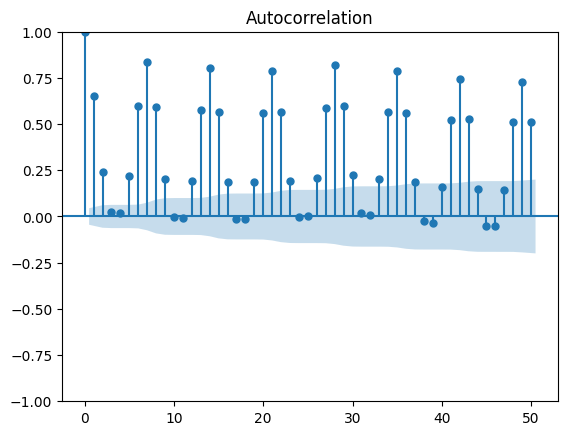

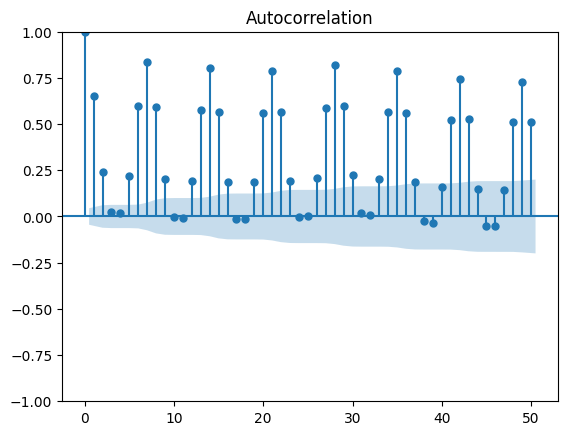

In [54]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts, lags=50)

In [55]:
df_merge

,id,item_id,dept_id,cat_id,store_id,state_id,day,sales,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,week,has_event
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,5,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,4,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,5,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,4,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,5,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,4,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,5,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,4,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,5,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58327365,FOODS_3_823_WI_3_validation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1913,1,2016-04-24,11613,6,2,4,2016,d_1913,NaN,NaN,NaN,NaN,0,0,0,16,0
58327366,FOODS_3_824_WI_3_validation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1913,0,2016-04-24,11613,6,2,4,2016,d_1913,NaN,NaN,NaN,NaN,0,0,0,16,0
58327367,FOODS_3_825_WI_3_validation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1913,0,2016-04-24,11613,6,2,4,2016,d_1913,NaN,NaN,NaN,NaN,0,0,0,16,0
58327368,FOODS_3_826_WI_3_validation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1913,3,2016-04-24,11613,6,2,4,2016,d_1913,NaN,NaN,NaN,NaN,0,0,0,16,0


In [57]:
# df_merge = df_sales_train_val.merge(df_calendar, left_on='day', right_on='d')

snap_cols = ['snap_CA','snap_TX','snap_WI']

snap_effect = df_merge.groupby(snap_cols)['sales'].mean().reset_index()

px.bar(
    snap_effect,
    x='snap_CA',  # puedes iterar por estado
    y='sales',
    title='Impacto SNAP en ventas (CA)'
)

In [70]:
df_merge['event_type_clean'] = df_merge['event_type_1'].fillna('No_event')

snap_effect = (
    df_merge[df_merge['state_id'] == 'CA']
    .groupby('event_type_clean')['sales']
    .mean()
    .reset_index()
)

px.bar(
    snap_effect,
    x='event_type_clean',
    y='sales',
    title='Impacto de eventos vs días normales (CA)'
)

In [63]:
aux = ['event_type_1']

snap_effect = df_merge[df_merge['state_id'] == 'TX'].groupby(aux)['sales'].mean().reset_index()

px.bar(
    snap_effect,
    x='event_type_1',  # puedes iterar por estado
    y='sales',
    title='Impacto de eventos en ventas (CA)'
)

In [69]:
df_event = df_merge[df_merge['event_name_1'].notna()]

top_event_items = (
    df_event
    .groupby('item_id')['sales']
    .sum()
    .reset_index()
    .sort_values('sales', ascending=False)
    .head(20)
)

px.bar(
    top_event_items,
    x='item_id',
    y='sales',
    title='Top 20 productos en días festivos'
)